In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [6]:
df = pd.read_excel("/content/healthcare_dataset.xlsx")
df.head()

,Patient_ID,Age,Gender,Disease,Blood_Pressure,Cholesterol,BMI,Diabetes,Heart_Disease,Treatment,Hospital_Stay,Recovery_Status
0,1,32,Male,Cancer,125,202,22.5,Yes,Yes,Observation,1,Recovered
1,2,45,Male,Flu,167,146,29.2,No,Yes,Observation,10,Recovered
2,3,18,Male,Cancer,144,227,23.6,Yes,No,Medication,2,Recovered
3,4,63,Female,Flu,123,151,32.6,Yes,No,Medication,9,Recovered
4,5,64,Male,Cancer,98,151,31.2,No,Yes,Surgery,14,Recovered


In [7]:
print(df.shape)

(500, 12)


In [8]:
print(df.columns)

Index(['Patient_ID', 'Age', 'Gender', 'Disease', 'Blood_Pressure',
       'Cholesterol', 'BMI', 'Diabetes', 'Heart_Disease', 'Treatment',
       'Hospital_Stay', 'Recovery_Status'],
      dtype='object')


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Patient_ID       500 non-null    int64  
 1   Age              500 non-null    int64  
 2   Gender           500 non-null    object 
 3   Disease          500 non-null    object 
 4   Blood_Pressure   500 non-null    int64  
 5   Cholesterol      500 non-null    int64  
 6   BMI              500 non-null    float64
 7   Diabetes         500 non-null    object 
 8   Heart_Disease    500 non-null    object 
 9   Treatment        500 non-null    object 
 10  Hospital_Stay    500 non-null    int64  
 11  Recovery_Status  500 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 47.0+ KB


In [10]:
df.describe()

,Patient_ID,Age,Blood_Pressure,Cholesterol,BMI,Hospital_Stay
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,250.500000,53.584000,136.454000,219.73400,27.796400,8.038000
std,144.481833,19.294858,26.501179,45.39163,5.720759,4.237507
min,1.000000,18.000000,90.000000,140.00000,18.000000,1.000000
25%,125.750000,37.000000,112.000000,179.00000,22.775000,4.000000
50%,250.500000,55.500000,137.000000,222.00000,27.800000,8.000000
75%,375.250000,70.000000,160.000000,257.00000,32.500000,11.250000
max,500.000000,85.000000,180.000000,300.00000,38.000000,15.000000


In [11]:
print(df.isnull().sum())

Patient_ID         0
Age                0
Gender             0
Disease            0
Blood_Pressure     0
Cholesterol        0
BMI                0
Diabetes           0
Heart_Disease      0
Treatment          0
Hospital_Stay      0
Recovery_Status    0
dtype: int64


In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [14]:
print(df["Recovery_Status"].value_counts())

Recovery_Status
Recovered     352
Recovering    107
Critical       41
Name: count, dtype: int64


In [15]:
df.mean(numeric_only=True)

,0
Patient_ID,250.5000
Age,53.5840
Blood_Pressure,136.4540
Cholesterol,219.7340
BMI,27.7964
Hospital_Stay,8.0380


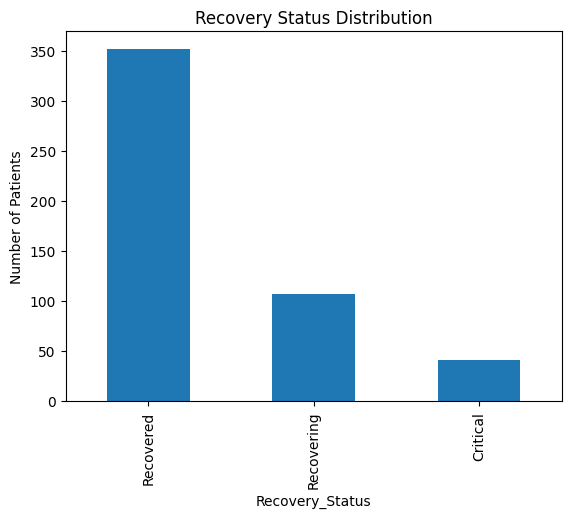

In [17]:
df["Recovery_Status"].value_counts().plot(kind="bar")

plt.title("Recovery Status Distribution")
plt.xlabel("Recovery_Status")
plt.ylabel("Number of Patients")

plt.show()

In [19]:
correlation = df.corr(numeric_only=True)

print(correlation)

                Patient_ID       Age  Blood_Pressure  Cholesterol       BMI  \
Patient_ID        1.000000 -0.016498        0.067152     0.097549 -0.054053   
Age              -0.016498  1.000000       -0.104522     0.051027 -0.034736   
Blood_Pressure    0.067152 -0.104522        1.000000     0.062085 -0.038664   
Cholesterol       0.097549  0.051027        0.062085     1.000000 -0.023353   
BMI              -0.054053 -0.034736       -0.038664    -0.023353  1.000000   
Hospital_Stay     0.067715  0.062303       -0.068037    -0.000302  0.036685   

                Hospital_Stay  
Patient_ID           0.067715  
Age                  0.062303  
Blood_Pressure      -0.068037  
Cholesterol         -0.000302  
BMI                  0.036685  
Hospital_Stay        1.000000  


In [21]:
from sklearn.model_selection import train_test_split

X = df.drop("Recovery_Status", axis=1)
y = df["Recovery_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42, class_weight='balanced')

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [23]:
from sklearn.ensemble import RandomForestClassifier

categorical_cols = X_train.select_dtypes(include='object').columns

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [24]:
prediction = model.predict(X_test)

print(prediction)

['Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovering' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovering' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovered' 

In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, prediction)

print("Accuracy:", accuracy)

Accuracy: 0.75


In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, prediction)

print(cm)

[[ 0  5  0]
 [ 0 75  2]
 [ 0 18  0]]


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

    Critical       0.00      0.00      0.00         5
   Recovered       0.77      0.97      0.86        77
  Recovering       0.00      0.00      0.00        18

    accuracy                           0.75       100
   macro avg       0.26      0.32      0.29       100
weighted avg       0.59      0.75      0.66       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
